<a href="https://colab.research.google.com/github/floranuta/Data_Circle/blob/main/notebooks/model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 2: Model development

In [11]:
# import necessary libraries here
from google.colab import drive

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

In [12]:
# load data
drive.mount("/content/drive")
train_value = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/training_set_values.csv")
train_label = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/training_set_labels.csv")

# merge values and labels on one table
train_data = pd.merge(train_value, train_label, on="id")
train_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,14/03/2011,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,06/03/2013,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,25/02/2013,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,28/01/2013,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,13/07/2011,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,03/05/2013,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,07/05/2011,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,11/04/2011,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,08/03/2011,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


**Task 1: Data cleaning and feature engineering**
- clean data so that data doesn't include null values
- encode categorical values into numerical values
- select features you want to use
- source: https://www.datacamp.com/tutorial/feature-engineering

In [13]:
# gloabal variables

TARGET_COLUMN = "status_group"
TARGET_MAPPING = {"functional": 0, "non functional": 1, "functional needs repair": 2}
FEATURE = ["quantity_group", "region", "payment_type", "extraction_type_class", "management", "quality_group", "pump_age", "status_group"]

In [14]:
class DataCleaner:

    def __init__(self) -> pd.DataFrame:
        """
        This class cleans raw data.

        ----------
        Parameters:
        features: list
          list of features
        """

        self.feature = FEATURE


    def extract_recorded_year(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Extract year from column recorded_year.

        ----------
        Parameters:
        dataframe: dataFrame

        ---------
        Returns:
        dataframe: dataframe
          dataframe which year_recorded was added after extracting year
        """

        dataframe["date_recorded"] = pd.to_datetime(dataframe['date_recorded'])

        # extract year from date_recorded
        dataframe["year_recorded"] = pd.DatetimeIndex(dataframe["date_recorded"]).year

        return dataframe


    def fill_extracttion_year(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Fill zero value with mean in a column extraction_year.


        ----------
        Parameters:
        dataframe: dataFrame

        ---------
        Returns:
        dataframe: dataframe
          dataframe after zero was filled with mean of construction_year
        """

        temp_df = dataframe[(dataframe["construction_year"] > 0)]
        mean_consturuction_year = temp_df["construction_year"].mean()

        dataframe["construction_year"] = dataframe['construction_year'].replace(0, mean_consturuction_year)

        return dataframe


    def get_pump_age(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate pump_age by recorded_year - consturction_year.

        ----------
        Parameters:
        dataframe: dataFrame

        ---------
        Returns:
        dataframe: dataframe
          dataframe that pump_age was added
        """

        # calculate the pump age
        dataframe["pump_age"] = dataframe["year_recorded"] - dataframe["construction_year"]

        return dataframe


    def remove_invalid_records(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Remove the rows where the pump_age is minus.

        ----------
        Parameters:
        dataframe: dataFrame

        ---------
        Returns:
        dataframe: dataframe
          dataframe after eliminating invailed data
        """

        initial_num_rows = len(dataframe)
        dataframe = dataframe.loc[dataframe["pump_age"] >= 0]
        dataframe = dataframe.reset_index()
        num_removed_row = len(dataframe) - initial_num_rows

        print(f"Removed {num_removed_row} invalid rows (negative pump_age). "
                f"Remaining rows: {len(dataframe)}")

        return dataframe


    def extract_feature(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Extract necessary features.

        ----------
        Parameters:
        dataframe: dataFrame

        ---------
        Returns:
        dataframe: dataframe
          dataframe contains only necessary features
        """

        return dataframe[self.feature]



    def preprocess(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Perform preprocessing.

        ----------
        Parameters:
        dataframe: dataFrame
          raw data

        ---------
        Returns:
        dataframe: dataframe
          cleaned dataframe
        """

        dataframe = self.extract_recorded_year(dataframe=dataframe)
        dataframe = self.fill_extracttion_year(dataframe=dataframe)
        dataframe = self.get_pump_age(dataframe=dataframe)
        dataframe = self.remove_invalid_records(dataframe=dataframe)
        cleaned_dataframe = self.extract_feature(dataframe=dataframe)

        print("Data cleaning completed.")

        return cleaned_dataframe

In [15]:
class Encoder:

    def __init__(self):
        """
        This class encodes categorical values in dataframe.

        ----------
        Parameters:
        feature_encoder: Object
          encoder to encode categorical features

        target_column: str or list
          column(s) name of target value

        taregt_encode_mapping: dict
          encoding schema for target value
        """

        self.feature_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.target_column = TARGET_COLUMN
        self.target_encode_mapping = TARGET_MAPPING


    def encode_target(self, categorical_target: pd.DataFrame) -> pd.DataFrame:
        """
        Apply label encoding to taregt column.

        ----------
        Parameters:
        categorical_target: dataFrame
          dataframe of target value

        ---------
        Returns:
        categorical_target: dataframe
          dataframe of encoded target value
        """

        categorical_target = categorical_target.map(self.target_encode_mapping)

        return categorical_target


    def encode_feature(self, categorical_feature: pd.DataFrame) -> pd.DataFrame:
        """
        Apply one-hot encoding to categorical features.
        Reference: https://datasensei.medium.com/how-to-transform-nominal-data-for-ml-with-onehotencoder-from-scikit-learn-f6febfefb3c6

        ----------
        Parameters:
        categorical_feature: dataFrame
          dataframe of feature value

        ---------
        Returns:
        one_hot_feature: dataframe
          dataframe of encoded feature value
        """

        # create a OneHotEncoder that ignores (0 encodes) unseen categories
        # and encode the categorical features for the example dataframe
        X_encoded = self.feature_encoder.fit_transform(categorical_feature)

        # # create the names for the one-hot encoded categorical features
        categorical_columns = [f'{col}_{cat}' for i, col in enumerate(categorical_feature.columns) for cat in self.feature_encoder.categories_[i]]

        # put the features into a dataframe and join with the original
        # numerical features
        one_hot_feature = pd.DataFrame(X_encoded, columns=categorical_columns)

        return one_hot_feature


    def encode_categorcial_value(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Encode categorical values.

        ----------
        Parameters:
        dataframe: dataFrame
          datframe before encoded

        ---------
        Returns:
        encoded_dataframe: dataframe
          encoded dataframe
        """


        # split the dataframe into its numerical and categorical components
        y_cat = dataframe[self.target_column]
        X_num = dataframe.select_dtypes(exclude='object')
        X_cat = dataframe.select_dtypes(include='object').drop(columns=self.target_column)


        # encode feature column
        X_cat_encoded = self.encode_feature(categorical_feature=X_cat)

        # encode target column
        y_cat_encoded = self.encode_target(categorical_target=y_cat)

        # join all dataframes

        encoded_dataframe = X_num.join(X_cat_encoded).join(y_cat_encoded)

        return encoded_dataframe

In [16]:
# clean data

cleaner = DataCleaner()

cleaned_data = cleaner.preprocess(train_data)
cleaned_data

Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
Data cleaning completed.


/tmp/ipython-input-1673652405.py:30: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataframe["date_recorded"] = pd.to_datetime(dataframe['date_recorded'])


,quantity_group,region,payment_type,extraction_type_class,management,quality_group,pump_age,status_group
0,enough,Iringa,annually,gravity,vwc,good,12.000000,functional
1,insufficient,Mara,never pay,gravity,wug,good,3.000000,functional
2,enough,Manyara,per bucket,gravity,vwc,good,4.000000,functional
3,dry,Mtwara,never pay,submersible,vwc,good,27.000000,non functional
4,seasonal,Kagera,never pay,gravity,other,good,14.185314,functional
...,...,...,...,...,...,...,...,...
59386,enough,Kilimanjaro,per bucket,gravity,water board,good,14.000000,functional
59387,enough,Iringa,annually,gravity,vwc,good,15.000000,functional
59388,enough,Mbeya,monthly,handpump,vwc,fluoride,14.185314,functional
59389,insufficient,Dodoma,never pay,handpump,vwc,good,14.185314,functional


In [17]:
# encode cleaned data

encoder = Encoder()

encoded_data = encoder.encode_categorcial_value(cleaned_data)
encoded_data

,pump_age,quantity_group_dry,quantity_group_enough,quantity_group_insufficient,quantity_group_seasonal,quantity_group_unknown,region_Arusha,region_Dar es Salaam,region_Dodoma,region_Iringa,...,management_water board,management_wua,management_wug,quality_group_colored,quality_group_fluoride,quality_group_good,quality_group_milky,quality_group_salty,quality_group_unknown,status_group
0,12.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,3.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,4.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,27.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,14.185314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59386,14.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
59387,15.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
59388,14.185314,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
59389,14.185314,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [18]:
encoded_data[["pump_age", "quantity_group_enough", "quantity_group_dry", "status_group"]]

,pump_age,quantity_group_enough,quantity_group_dry,status_group
0,12.000000,1.0,0.0,0
1,3.000000,0.0,0.0,0
2,4.000000,1.0,0.0,0
3,27.000000,0.0,1.0,1
4,14.185314,0.0,0.0,0
...,...,...,...,...
59386,14.000000,1.0,0.0,0
59387,15.000000,1.0,0.0,0
59388,14.185314,1.0,0.0,0
59389,14.185314,0.0,0.0,0


**Task 2: Implment base pipeline**
- Select ML algorithm you want to use
- Implement algorithm you chosen, K-fold cross validation, training and prediction
- source for K-fold corss validation with code: https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right
- source for selecting machine learnig model: https://ujangriswanto08.medium.com/top-algorithms-for-multi-class-classification-in-machine-learning-ed8642ca5440

In [19]:
def oversample(X: np.array, y: np.array, method: str) -> np.array:
    """ Randomly oversample minority class """

    if method == "basic":
        # Over Sampling Minority class
        print("Oversample with basic oversampling")
        OverS = RandomOverSampler(random_state=42)

    elif method == "smote":
        # over sample with SMOTE
        # https://medium.com/data-science/class-imbalance-strategies-a-visual-guide-with-code-8bc8fae71e1a
        print("Oversample with SMOTE")
        OverS = SMOTE(random_state=0)

    elif method == "adasyn":
        # oversample with ADASYN
        # https://medium.com/data-science/class-imbalance-strategies-a-visual-guide-with-code-8bc8fae71e1a
        print("Oversample with ADASYN")
        OverS = ADASYN(random_state=0)

    # Fit predictor (x variable) and target (y variable) using fit_resample()
    X_Over, y_Over = OverS.fit_resample(X, y)

    # Printing number of samples in each class after Over-Sampling
    print("Before Oversampling -> After Oversampling")
    print(f"functional:  {np.count_nonzero(y == TARGET_MAPPING["functional"])} -> {np.count_nonzero(y_Over == TARGET_MAPPING["functional"])}")
    print(f"non functional: {np.count_nonzero(y == TARGET_MAPPING["non functional"])} -> {np.count_nonzero(y_Over == TARGET_MAPPING["non functional"])}")
    print(f"functional needs repair: {np.count_nonzero(y == TARGET_MAPPING["functional needs repair"])} -> {np.count_nonzero(y_Over == TARGET_MAPPING["functional needs repair"])}")

    return X_Over, y_Over



In [20]:
# model base line

def run(data: pd.DataFrame,
        is_oversample: bool,
        classifier: object,
        k_fold_split: int = 10,
        method: str=None) -> list:

    # separte feature and target values
    X = data.drop(TARGET_COLUMN, axis=1).to_numpy()
    y = data[TARGET_COLUMN].to_numpy()

    # apply oversampling
    if is_oversample == True:
        X, y = oversample(X, y, method)

    # define number of fold
    kf = KFold(n_splits=k_fold_split)

    y_test_all = []
    y_pred_all = []
    iteration = 1
    accuracy_all = []


    # apply K-fold cross validation
    # https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right

    for train_index, test_index in kf.split(X):

        print(f"ITERATION {iteration} / {kf.n_splits}")

        # split data into train and test data
        # print("TRAIN:", len(train_index), "TEST:", len(test_index))
        # print("TRAIN:", train_index, "TEST:", test_index)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]


        # train a model
        classifier.fit(X_train, y_train)

        # predict pump status
        y_pred = classifier.predict(X_test)

        # print("Tuned Hyperparameters: {}".format(classifier.best_params_))

        # show accuracy
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
        acc_score = accuracy_score(y_test, y_pred, normalize=True)
        accuracy_all.append(acc_score)
        print("accuracy_score: ", acc_score)

        # save all true and predicted value
        y_test_all.append(y_test)
        y_pred_all.append(y_pred)

        iteration += 1

    return y_test_all, y_pred_all, accuracy_all

**Task 3: Implement evaluation mtrix and tune hyperparamter**
- Implement classification report (accuracy, precision, F1 score etc.) and heat map and so on
- Tune hyperparameter
- Select appropriate evaluation matrix and hyperparameter optimization
- source for evaluation matrix: https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/

In [21]:
def evaluate_model(y_test_all: list,
                  y_pred_all: list,
                  accuracy_all: list,
                  ) -> None:

    # flat out matrix into single list
    y_test_res = [val for y_test in y_test_all for val in y_test]
    y_pred_res = [val for y_pred in y_pred_all for val in y_pred]

    # create classification report
    cr = classification_report(y_test_res, y_pred_res, target_names=list(TARGET_MAPPING.keys()))
    print(cr)

    plt.figure(figsize=[8,6])
    plt.plot(accuracy_all)
    plt.title("Accuracy")
    plt.xlabel("Number of iteration")
    plt.ylabel("Accuracy")
    plt.show()
    plt.close()

    # Create a confusion matrix
    # https://medium.com/@sanyagubrani/evaluating-multi-class-classification-model-using-confusion-matrix-in-python-4d9344084dfa
    cm = confusion_matrix(y_test_res, y_pred_res, normalize="all")

    # Plot the confusion matrix
    plt.figure(figsize=[8,6])
    sns.heatmap(cm, annot=True, cmap='YlGnBu', xticklabels=list(TARGET_MAPPING.keys()), yticklabels=list(TARGET_MAPPING.keys()))
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Confusion Matrix',fontsize=16)
    plt.show()


# Experiment

## Model comparison

### Logistics regression with softmax

In [22]:
### Logistic regression with softmax
classifier = LogisticRegression(C=1e5, solver='newton-cg')

# define a range of c values usinf logarithmis scale
# c_space = np.logspace(-5, 8, 15)
# param_grid = {'C': c_space}

# define the gridsearch to tune hyperparameter
# classifier = GridSearchCV(model, param_grid)

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="smote")

Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.587603305785124
ITERATION 2 / 40
accuracy_score:  0.6045454545454545
ITERATION 3 / 40
accuracy_score:  0.6008264462809917
ITERATION 4 / 40
accuracy_score:  0.6024793388429752
ITERATION 5 / 40
accuracy_score:  0.5975206611570248
ITERATION 6 / 40
accuracy_score:  0.5998346424142208
ITERATION 7 / 40
accuracy_score:  0.5878462174452252
ITERATION 8 / 40
accuracy_score:  0.5919801570897065
ITERATION 9 / 40
accuracy_score:  0.5758577924762298
ITERATION 10 / 40
accuracy_score:  0.5907399751963621
ITERATION 11 / 40
accuracy_score:  0.6035551880942538
ITERATION 12 / 40
accuracy_score:  0.5775113683340223
ITERATION 13 / 40
accuracy_score:  0.583298883836296
ITERATION 14 / 40
accuracy_score:  0.5791649441918147
ITERATION 15 / 40
accuracy_score:  0.5886730053741215
ITERATION 16 / 40
accuracy_score:  0.58

                         precision    recall  f1-score   support

             functional       0.56      0.59      0.58     32255
         non functional       0.71      0.59      0.64     32255
functional needs repair       0.57      0.64      0.60     32255

               accuracy                           0.60     96765
              macro avg       0.61      0.60      0.61     96765
           weighted avg       0.61      0.60      0.61     96765



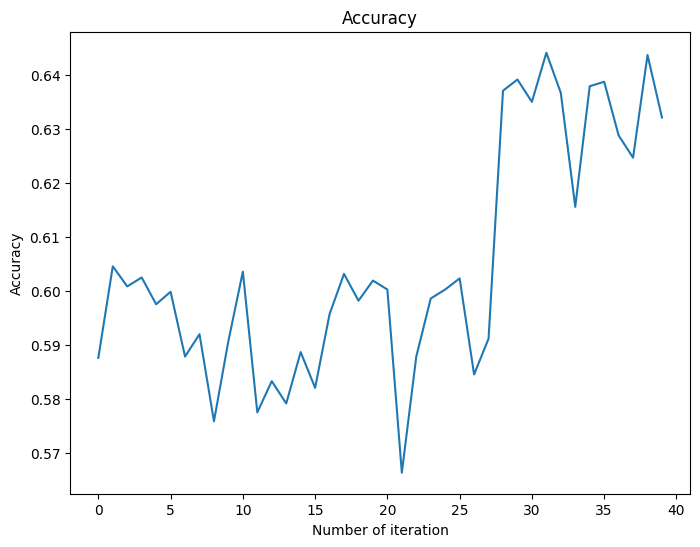

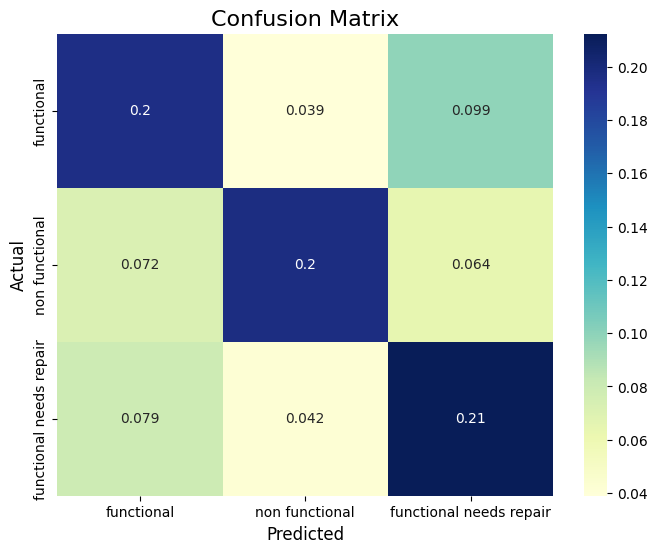

In [23]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Linear classifiers (SVM, logistic regression, etc.) with SGD training.

In [24]:
### Linear classifiers (SVM, logistic regression, etc.) with SGD training.
# One vs. Rest classifcation
classifier = SGDClassifier(max_iter=1000, tol=1e-3)

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="smote")

Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.6239669421487604
ITERATION 2 / 40
accuracy_score:  0.606198347107438
ITERATION 3 / 40
accuracy_score:  0.6049586776859505
ITERATION 4 / 40
accuracy_score:  0.5921487603305785
ITERATION 5 / 40
accuracy_score:  0.5462809917355372
ITERATION 6 / 40
accuracy_score:  0.6105828854898718
ITERATION 7 / 40
accuracy_score:  0.6114096734187681
ITERATION 8 / 40
accuracy_score:  0.6200909466721786
ITERATION 9 / 40
accuracy_score:  0.49359239355105416
ITERATION 10 / 40
accuracy_score:  0.6101694915254238
ITERATION 11 / 40
accuracy_score:  0.621744522529971
ITERATION 12 / 40
accuracy_score:  0.5857792476229847
ITERATION 13 / 40
accuracy_score:  0.6155436130632492
ITERATION 14 / 40
accuracy_score:  0.5423728813559322
ITERATION 15 / 40
accuracy_score:  0.4989665150888797
ITERATION 16 / 40
accuracy_score:  0.5

                         precision    recall  f1-score   support

             functional       0.55      0.59      0.57     32255
         non functional       0.72      0.58      0.64     32255
functional needs repair       0.58      0.64      0.61     32255

               accuracy                           0.60     96765
              macro avg       0.61      0.60      0.61     96765
           weighted avg       0.61      0.60      0.61     96765



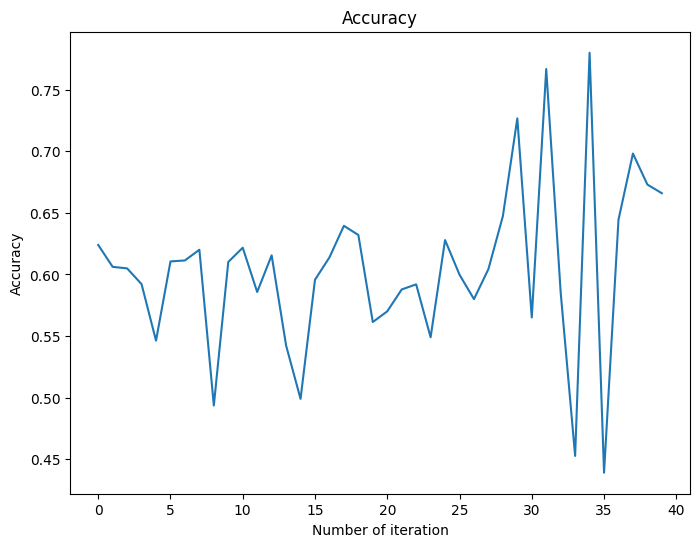

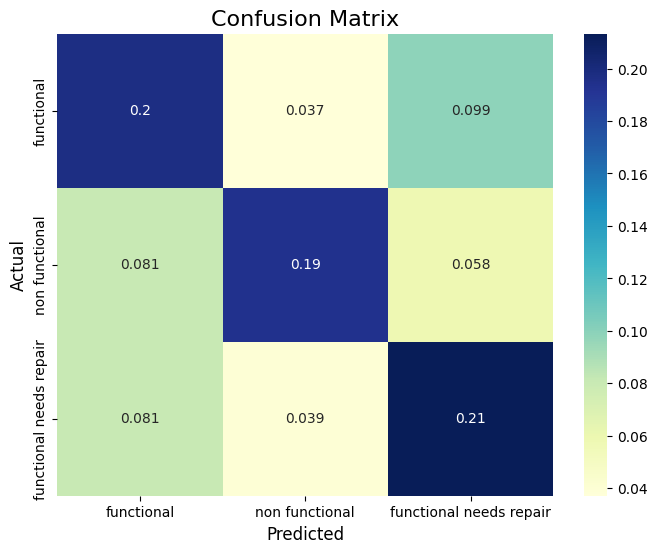

In [25]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Decision tree

In [26]:
### Decision tree
# Source: https://www.datacamp.com/tutorial/decision-tree-classification-python
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="smote")

Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.702892561983471
ITERATION 2 / 40
accuracy_score:  0.7285123966942149
ITERATION 3 / 40
accuracy_score:  0.7231404958677686
ITERATION 4 / 40
accuracy_score:  0.6987603305785124
ITERATION 5 / 40
accuracy_score:  0.7202479338842975
ITERATION 6 / 40
accuracy_score:  0.7168251343530384
ITERATION 7 / 40
accuracy_score:  0.6969822240595287
ITERATION 8 / 40
accuracy_score:  0.7085572550640761
ITERATION 9 / 40
accuracy_score:  0.7052501033484911
ITERATION 10 / 40
accuracy_score:  0.7035965274906987
ITERATION 11 / 40
accuracy_score:  0.7362546506821
ITERATION 12 / 40
accuracy_score:  0.7031831335262505
ITERATION 13 / 40
accuracy_score:  0.7159983464241422
ITERATION 14 / 40
accuracy_score:  0.7143447705663497
ITERATION 15 / 40
accuracy_score:  0.6978090119884249
ITERATION 16 / 40
accuracy_score:  0.7151

                         precision    recall  f1-score   support

             functional       0.71      0.73      0.72     32255
         non functional       0.82      0.71      0.76     32255
functional needs repair       0.76      0.84      0.80     32255

               accuracy                           0.76     96765
              macro avg       0.76      0.76      0.76     96765
           weighted avg       0.76      0.76      0.76     96765



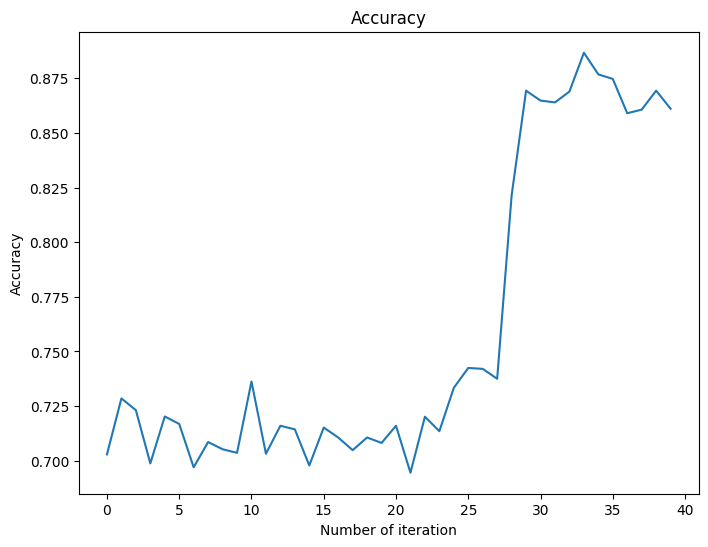

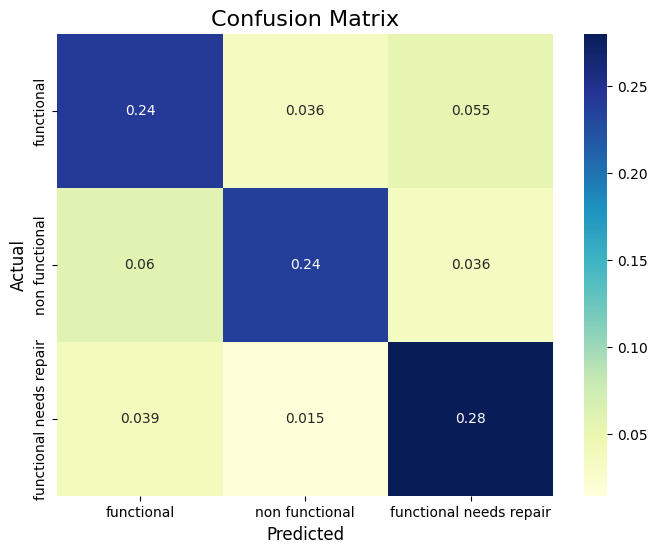

In [27]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Random forest

### Transfer learning

### more expolore with combination of sampling and model

In [44]:
### Logistic regression with softmax
classifier = LogisticRegression(C=1e5, solver='newton-cg')

# define a range of c values usinf logarithmis scale
# c_space = np.logspace(-5, 8, 15)
# param_grid = {'C': c_space}

# define the gridsearch to tune hyperparameter
# classifier = GridSearchCV(model, param_grid)

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=50,
                                            method="basic")

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 50
accuracy_score:  0.5919421487603306
ITERATION 2 / 50
accuracy_score:  0.6012396694214877
ITERATION 3 / 50
accuracy_score:  0.5981404958677686
ITERATION 4 / 50
accuracy_score:  0.6141528925619835
ITERATION 5 / 50
accuracy_score:  0.59400826446281
ITERATION 6 / 50
accuracy_score:  0.6017561983471075
ITERATION 7 / 50
accuracy_score:  0.5914256198347108
ITERATION 8 / 50
accuracy_score:  0.5929752066115702
ITERATION 9 / 50
accuracy_score:  0.5903925619834711
ITERATION 10 / 50
accuracy_score:  0.5914256198347108
ITERATION 11 / 50
accuracy_score:  0.5650826446280992
ITERATION 12 / 50
accuracy_score:  0.5986570247933884
ITERATION 13 / 50
accuracy_score:  0.59349173553719
ITERATION 14 / 50
accuracy_score:  0.6012396694214877
ITERATION 15 / 50
accuracy_score:  0.5816115702479339
ITERATION 16 / 50
accuracy_s

                         precision    recall  f1-score   support

             functional       0.56      0.59      0.57     32255
         non functional       0.70      0.59      0.64     32255
functional needs repair       0.56      0.62      0.59     32255

               accuracy                           0.60     96765
              macro avg       0.61      0.60      0.60     96765
           weighted avg       0.61      0.60      0.60     96765



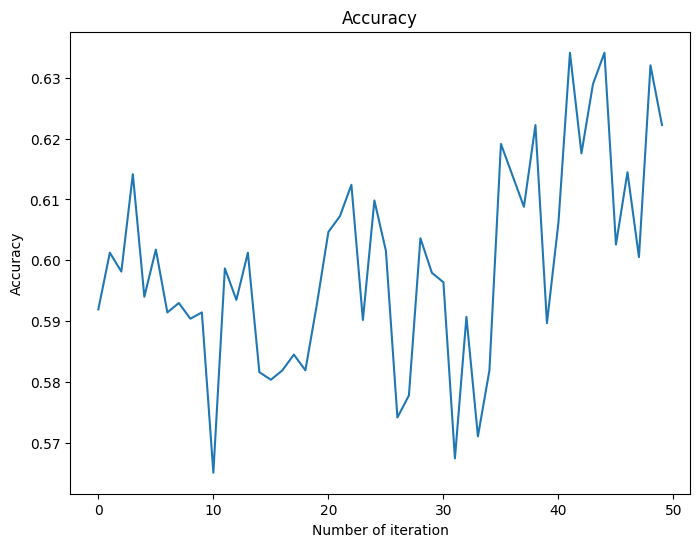

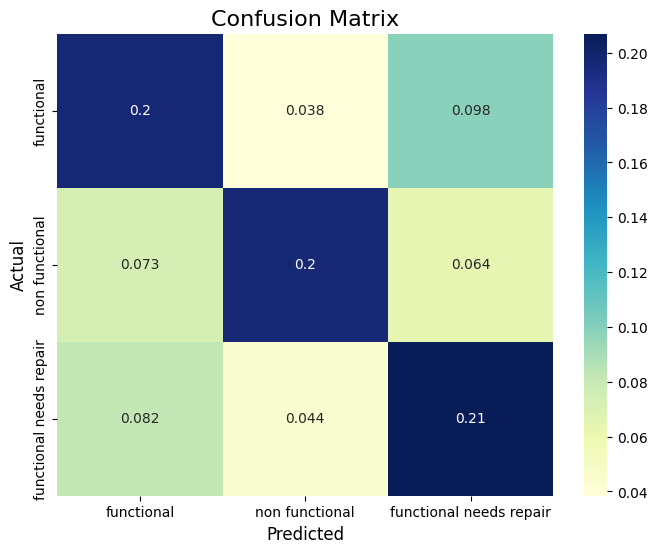

In [45]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

In [46]:
### Linear classifiers (SVM, logistic regression, etc.) with SGD training.
# One vs. Rest classifcation
classifier = SGDClassifier(max_iter=1000, tol=1e-3)

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=50,
                                            method="basic")

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 50
accuracy_score:  0.5800619834710744
ITERATION 2 / 50
accuracy_score:  0.6167355371900827
ITERATION 3 / 50
accuracy_score:  0.6394628099173554
ITERATION 4 / 50
accuracy_score:  0.6611570247933884
ITERATION 5 / 50
accuracy_score:  0.5743801652892562
ITERATION 6 / 50
accuracy_score:  0.5914256198347108
ITERATION 7 / 50
accuracy_score:  0.5645661157024794
ITERATION 8 / 50
accuracy_score:  0.5759297520661157
ITERATION 9 / 50
accuracy_score:  0.49793388429752067
ITERATION 10 / 50
accuracy_score:  0.47417355371900827
ITERATION 11 / 50
accuracy_score:  0.6177685950413223
ITERATION 12 / 50
accuracy_score:  0.6105371900826446
ITERATION 13 / 50
accuracy_score:  0.5650826446280992
ITERATION 14 / 50
accuracy_score:  0.5919421487603306
ITERATION 15 / 50
accuracy_score:  0.65599173553719
ITERATION 16 / 50
accura

                         precision    recall  f1-score   support

             functional       0.56      0.54      0.55     32255
         non functional       0.67      0.59      0.63     32255
functional needs repair       0.54      0.62      0.57     32255

               accuracy                           0.58     96765
              macro avg       0.59      0.58      0.58     96765
           weighted avg       0.59      0.58      0.58     96765



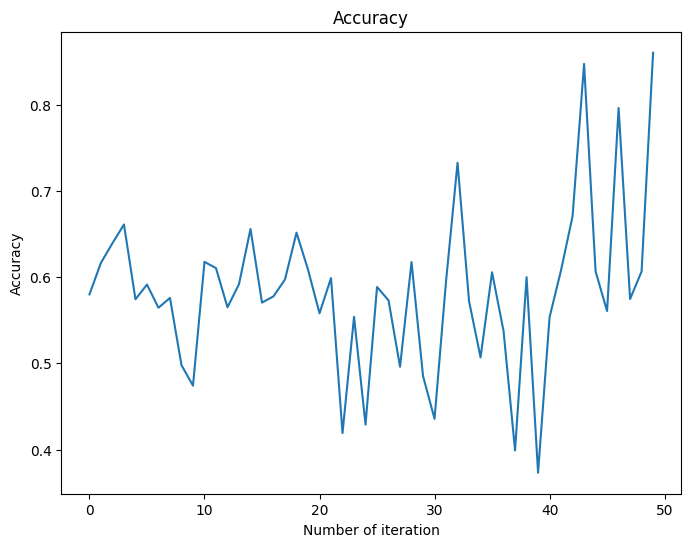

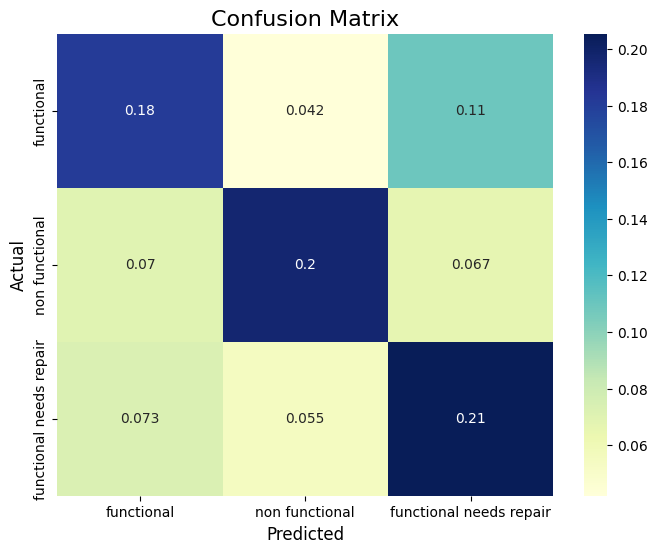

In [47]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

In [40]:
### Decision tree
# Source: https://www.datacamp.com/tutorial/decision-tree-classification-python
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="basic")

Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.7020661157024793
ITERATION 2 / 40
accuracy_score:  0.7148760330578512
ITERATION 3 / 40
accuracy_score:  0.7107438016528925
ITERATION 4 / 40
accuracy_score:  0.6966942148760331
ITERATION 5 / 40
accuracy_score:  0.7132231404958678
ITERATION 6 / 40
accuracy_score:  0.7159983464241422
ITERATION 7 / 40
accuracy_score:  0.70111616370401
ITERATION 8 / 40
accuracy_score:  0.7019429516329062
ITERATION 9 / 40
accuracy_score:  0.7027697395618024
ITERATION 10 / 40
accuracy_score:  0.6953286482017362
ITERATION 11 / 40
accuracy_score:  0.7284001653575858
ITERATION 12 / 40
accuracy_score:  0.6978090119884249
ITERATION 13 / 40
accuracy_score:  0.7135179826374535
ITERATION 14 / 40
accuracy_score:  0.7073170731707317
ITERATION 15 / 40
accuracy_score:  0.69450186027284
ITERATION 16 / 40
accuracy_s

                         precision    recall  f1-score   support

             functional       0.71      0.68      0.70     32255
         non functional       0.82      0.72      0.77     32255
functional needs repair       0.72      0.84      0.78     32255

               accuracy                           0.75     96765
              macro avg       0.75      0.75      0.75     96765
           weighted avg       0.75      0.75      0.75     96765



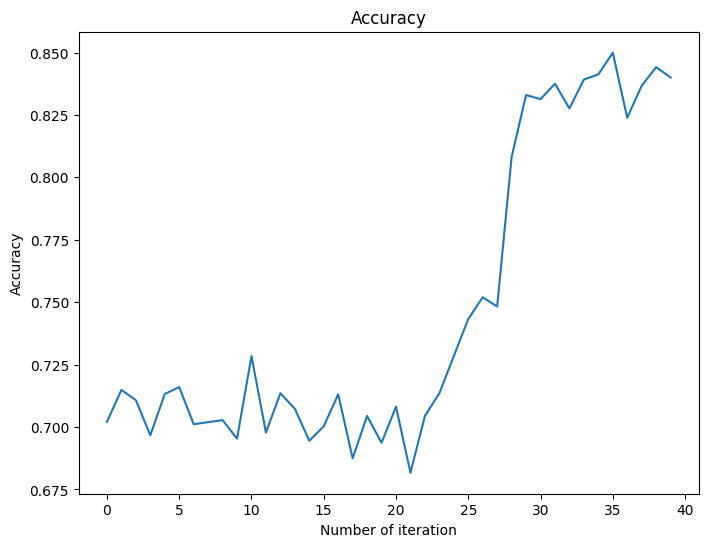

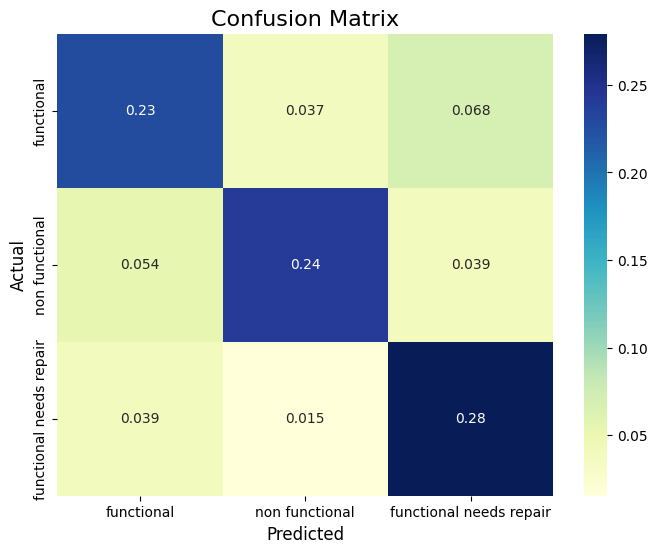

In [41]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

## Oversampling

### Without oversampling

In [28]:
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=False,
                                            classifier=classifier,
                                            k_fold_split=40)

ITERATION 1 / 40
accuracy_score:  0.7501683501683502
ITERATION 2 / 40
accuracy_score:  0.7643097643097643
ITERATION 3 / 40
accuracy_score:  0.7696969696969697
ITERATION 4 / 40
accuracy_score:  0.7656565656565657
ITERATION 5 / 40
accuracy_score:  0.7663299663299663
ITERATION 6 / 40
accuracy_score:  0.7380471380471381
ITERATION 7 / 40
accuracy_score:  0.7622895622895622
ITERATION 8 / 40
accuracy_score:  0.7777777777777778
ITERATION 9 / 40
accuracy_score:  0.7575757575757576
ITERATION 10 / 40
accuracy_score:  0.767003367003367
ITERATION 11 / 40
accuracy_score:  0.7481481481481481
ITERATION 12 / 40
accuracy_score:  0.7521885521885522
ITERATION 13 / 40
accuracy_score:  0.7602693602693603
ITERATION 14 / 40
accuracy_score:  0.7494949494949495
ITERATION 15 / 40
accuracy_score:  0.7447811447811448
ITERATION 16 / 40
accuracy_score:  0.767003367003367
ITERATION 17 / 40
accuracy_score:  0.7791245791245791
ITERATION 18 / 40
accuracy_score:  0.775084175084175
ITERATION 19 / 40
accuracy_score:  0.772

                         precision    recall  f1-score   support

             functional       0.76      0.88      0.81     32255
         non functional       0.79      0.70      0.75     22819
functional needs repair       0.46      0.19      0.27      4317

               accuracy                           0.76     59391
              macro avg       0.67      0.59      0.61     59391
           weighted avg       0.75      0.76      0.75     59391



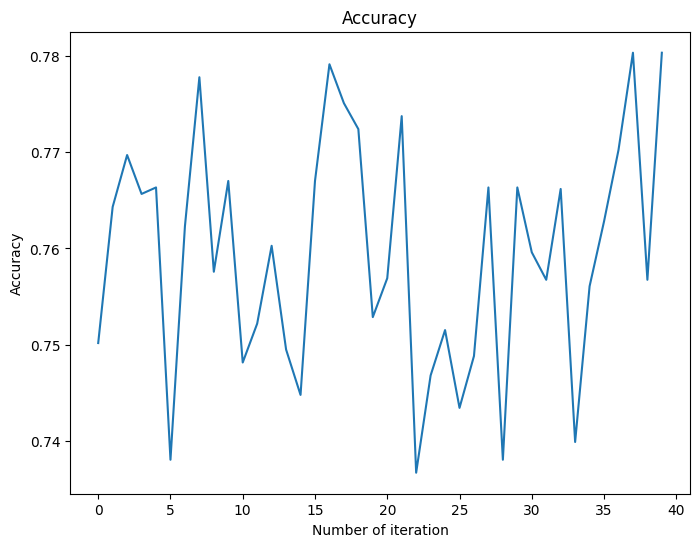

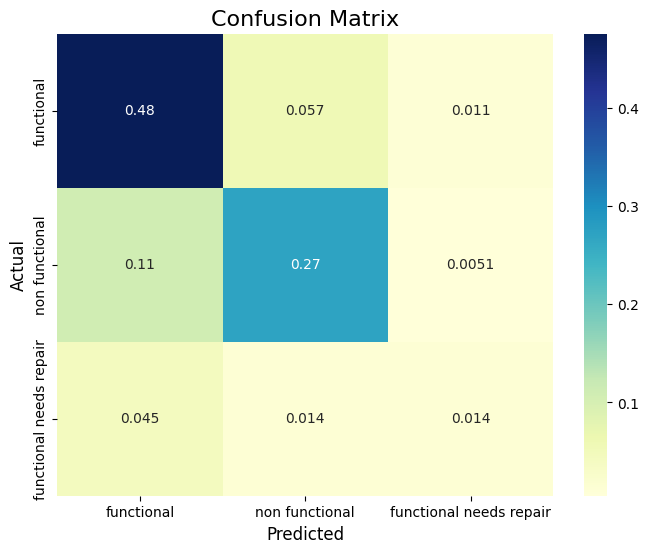

In [29]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Basic oversampling

In [30]:
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="basic")


Oversample with basic oversampling
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.7024793388429752
ITERATION 2 / 40
accuracy_score:  0.7181818181818181
ITERATION 3 / 40
accuracy_score:  0.7123966942148761
ITERATION 4 / 40
accuracy_score:  0.6954545454545454
ITERATION 5 / 40
accuracy_score:  0.7140495867768595
ITERATION 6 / 40
accuracy_score:  0.7135179826374535
ITERATION 7 / 40
accuracy_score:  0.6998759818106656
ITERATION 8 / 40
accuracy_score:  0.70111616370401
ITERATION 9 / 40
accuracy_score:  0.7060768912773874
ITERATION 10 / 40
accuracy_score:  0.69450186027284
ITERATION 11 / 40
accuracy_score:  0.7275733774286895
ITERATION 12 / 40
accuracy_score:  0.6969822240595287
ITERATION 13 / 40
accuracy_score:  0.7139313766019016
ITERATION 14 / 40
accuracy_score:  0.7081438610996279
ITERATION 15 / 40
accuracy_score:  0.6949152542372882
ITERATION 16 / 40
accuracy_s

                         precision    recall  f1-score   support

             functional       0.71      0.68      0.70     32255
         non functional       0.82      0.72      0.77     32255
functional needs repair       0.72      0.84      0.78     32255

               accuracy                           0.75     96765
              macro avg       0.75      0.75      0.75     96765
           weighted avg       0.75      0.75      0.75     96765



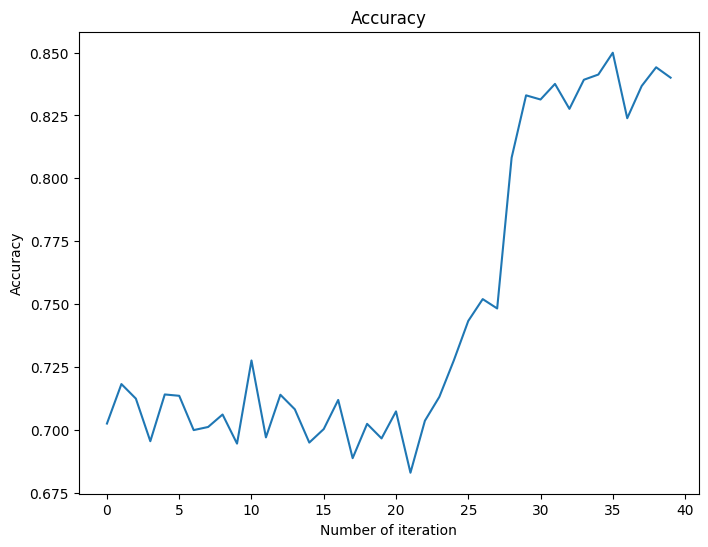

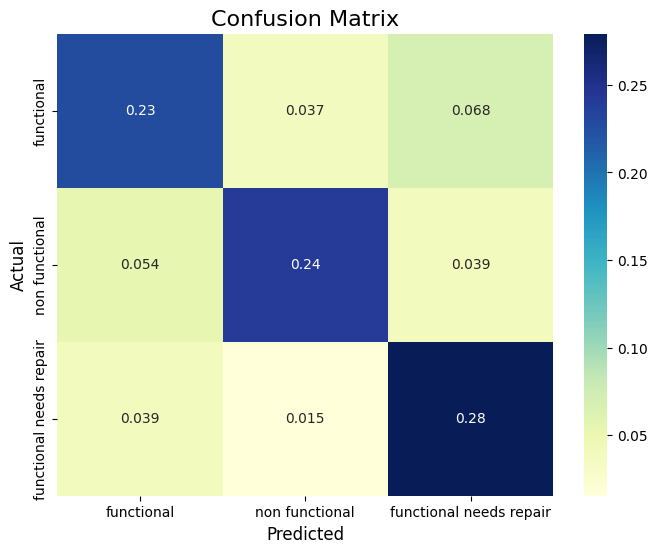

In [31]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

### Oversample with SMOTE algorithms

In [32]:
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="smote")


Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32255
functional needs repair: 4317 -> 32255
ITERATION 1 / 40
accuracy_score:  0.7045454545454546
ITERATION 2 / 40
accuracy_score:  0.728099173553719
ITERATION 3 / 40
accuracy_score:  0.7198347107438017
ITERATION 4 / 40
accuracy_score:  0.7
ITERATION 5 / 40
accuracy_score:  0.7194214876033058
ITERATION 6 / 40
accuracy_score:  0.7172385283174866
ITERATION 7 / 40
accuracy_score:  0.6969822240595287
ITERATION 8 / 40
accuracy_score:  0.7093840429929723
ITERATION 9 / 40
accuracy_score:  0.7064902852418354
ITERATION 10 / 40
accuracy_score:  0.7031831335262505
ITERATION 11 / 40
accuracy_score:  0.7362546506821
ITERATION 12 / 40
accuracy_score:  0.701529557668458
ITERATION 13 / 40
accuracy_score:  0.7164117403885903
ITERATION 14 / 40
accuracy_score:  0.7143447705663497
ITERATION 15 / 40
accuracy_score:  0.6978090119884249
ITERATION 16 / 40
accuracy_score:  0.7143447705663497
ITE

                         precision    recall  f1-score   support

             functional       0.71      0.73      0.72     32255
         non functional       0.82      0.71      0.76     32255
functional needs repair       0.76      0.84      0.80     32255

               accuracy                           0.76     96765
              macro avg       0.76      0.76      0.76     96765
           weighted avg       0.76      0.76      0.76     96765



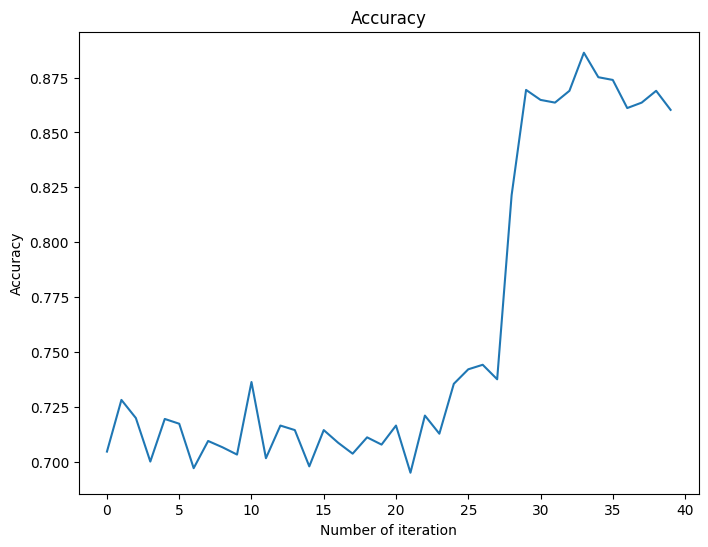

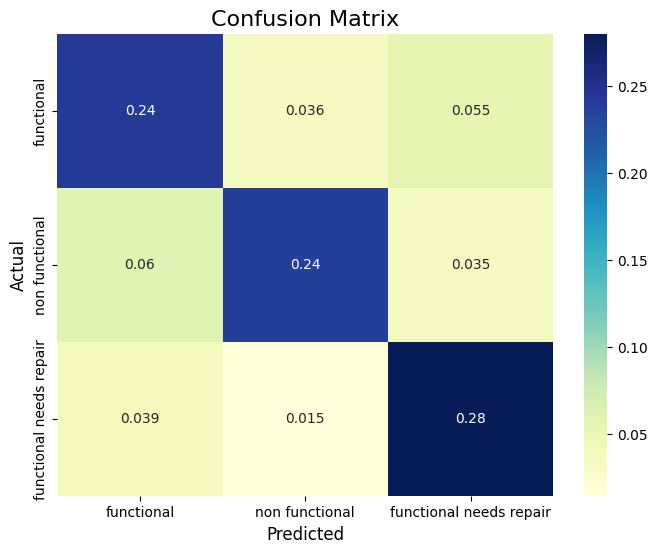

In [33]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)


### Oversample with ADASYN algorithms

In [34]:
classifier = DecisionTreeClassifier()

y_test_all, y_pred_all, accuracy_all = run(data=encoded_data,
                                            is_oversample=True,
                                            classifier=classifier,
                                            k_fold_split=40,
                                            method="adasyn")

Oversample with ADASYN
Before Oversampling -> After Oversampling
functional:  32255 -> 32255
non functional: 22819 -> 32486
functional needs repair: 4317 -> 31842
ITERATION 1 / 40
accuracy_score:  0.6977225672877847
ITERATION 2 / 40
accuracy_score:  0.7076604554865424
ITERATION 3 / 40
accuracy_score:  0.7039337474120083
ITERATION 4 / 40
accuracy_score:  0.6923395445134576
ITERATION 5 / 40
accuracy_score:  0.715527950310559
ITERATION 6 / 40
accuracy_score:  0.7010351966873706
ITERATION 7 / 40
accuracy_score:  0.694824016563147
ITERATION 8 / 40
accuracy_score:  0.705175983436853
ITERATION 9 / 40
accuracy_score:  0.7068322981366459
ITERATION 10 / 40
accuracy_score:  0.6935817805383023
ITERATION 11 / 40
accuracy_score:  0.724223602484472
ITERATION 12 / 40
accuracy_score:  0.6910973084886128
ITERATION 13 / 40
accuracy_score:  0.715527950310559
ITERATION 14 / 40
accuracy_score:  0.6952380952380952
ITERATION 15 / 40
accuracy_score:  0.687784679089027
ITERATION 16 / 40
accuracy_score:  0.70103

                         precision    recall  f1-score   support

             functional       0.69      0.68      0.69     32255
         non functional       0.73      0.67      0.70     32486
functional needs repair       0.71      0.77      0.74     31842

               accuracy                           0.71     96583
              macro avg       0.71      0.71      0.71     96583
           weighted avg       0.71      0.71      0.71     96583



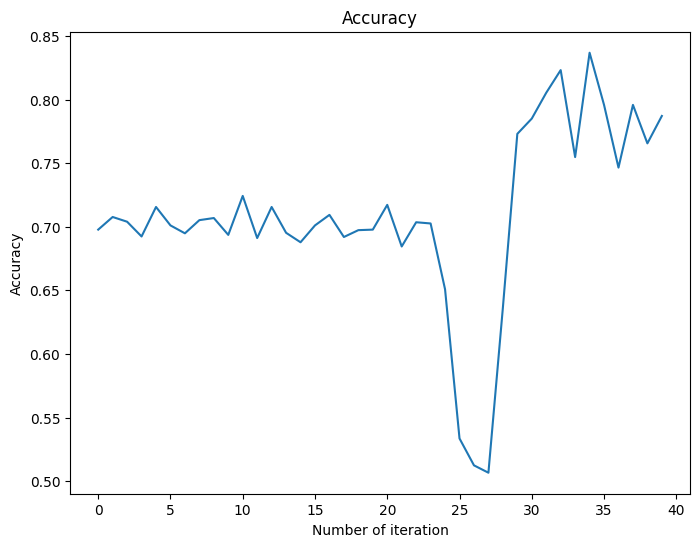

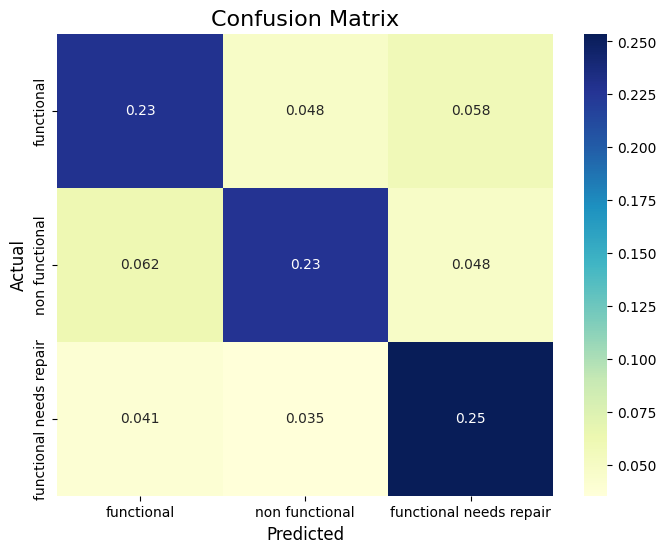

In [35]:
evaluate_model(y_test_all=y_test_all,
               y_pred_all=y_pred_all,
               accuracy_all=accuracy_all)

# Summary report from experiement

**Model comparison:**  
We experimented with those models:   
*   Logistic regression with softmax
*   Linear clssifier with Stochastic Gradient Descent training
*   Decision Tree

Results:  
Desicion tree peformed the best. But all models struggled with predicting "Functional needs repair" class without oversampling.









**Class imbalance:**  
We experimented with those settings to see how class imbalance infleunce the performance:  
*   Without oversampling
*   With basic oversampling
*   With SMOTE oversampling
*   With ADASYN oversampling

Results:   
Oversampling significantly improved the predicion in "Functional needs repair" class. SMOTE algorithm slightly outperformed other oversampling methods.   


**Feature engineering**
* quantity_group
* region
* payment_type
* extraction_type_class
* management
* quality_group
* pump_age (i.e. recorded_year - extraction_year)

We experiemented including and excluding pump_age. Including pump_age slightly outperformed excluding pump_age.